---

# LESSON 21: BAR CHARTS

---

>---
>**Bar Charts** are used to compare values across different categories
>
>- `ax.bar(` *`category labels`*, *`bar heights`*, *formatting options* `)`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin'])

df = df.groupby('region_name', as_index=False)['median_active_list_price'].mean().round()
df = df.rename(columns={'median_active_list_price':'price'})
display(df.head())

avg_ca = df.price.mean()
print(f"\nAverage California Counties: {avg_ca:.2f}")

,region_name,price
0,Los Angeles,768225.0
1,San Diego,716818.0
2,San Francisco,1358263.0



Average California Counties: 947768.67


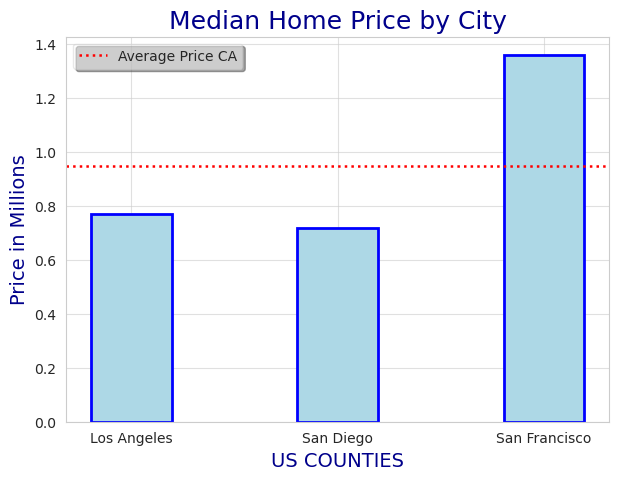

In [3]:
fig, ax = plt.subplots(figsize=(7,5), dpi=100)
ax.bar(df['region_name'], df['price']/1e6,
       width=0.39, linewidth=2,
       edgecolor='blue',
       facecolor='lightblue', 
      )

ax.set_title('Median Home Price by City', fontsize=18, color='darkblue')
ax.set_xlabel('US COUNTIES', fontsize=14, color='darkblue')
ax.set_ylabel('Price in Millions', fontsize=14, color='darkblue')

ax.axhline(y=avg_ca/1e6, linewidth=1.8, ls=':', color='red', label='Average Price CA')

ax.legend(loc='upper left', shadow=True, fancybox=True,
          framealpha=0.45,)

ax.grid(alpha=0.6, ls='-')
plt.show()

<br><br>

---

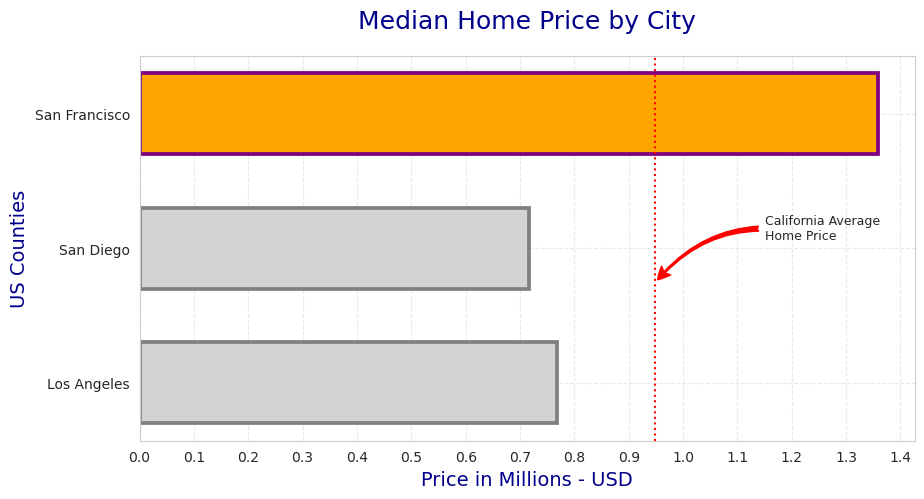

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.barh(y=df['region_name'], width=df['price']/1e6,
        facecolor=['lightgray', 'lightgray', 'orange'], 
        edgecolor=['gray', 'gray','purple'],
        linewidth=2.7, height=0.6
       )

ax.set_title('Median Home Price by City', fontsize=18, color='darkblue', y=1.05)
ax.set_xlabel('Price in Millions - USD', fontsize=14, color='darkblue')
ax.set_ylabel('US Counties', fontsize=14, color='darkblue')

ax.axvline(x=avg_ca/1e6, linewidth=1.5, linestyle=':', color='red', label='CA Average')

ax.annotate(text='California Average\nHome Price',
            xy=(0.95, 0.75),
            xytext=(1.15, 1.25),
            horizontalalignment = 'left',
            verticalalignment = 'top',
            fontsize=9,
            arrowprops=dict(
                arrowstyle='fancy, head_width=1, head_length=1',
                color='red',
                relpos=(0, 0.5),
                connectionstyle='angle3, angleA=0, angleB=50'
           )
)
ax.set_xticks(np.arange(0, 1.5, 0.1))
ax.grid(linestyle='--', alpha=0.45)
plt.show()

<br><br>

---

# LABORATORY

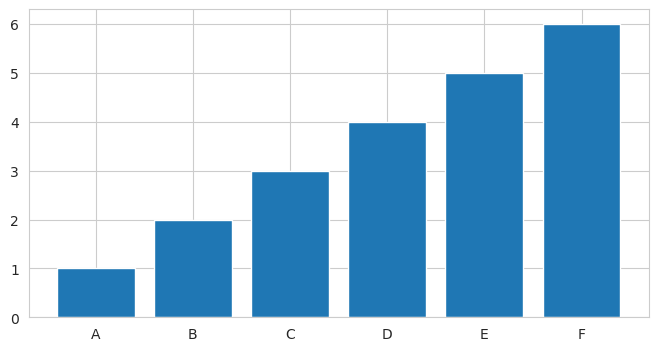

In [12]:
labels = ['A', 'B', 'C', 'D', 'E', 'F']
values = list(range(1,7))

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.bar(labels, values)
plt.show()

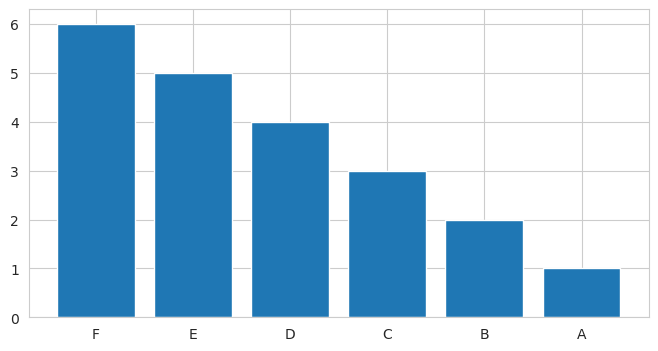

In [21]:
labels = ['A', 'B', 'C', 'D', 'E', 'F']
values = list(range(1,7))

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.bar(labels[::-1], values[::-1])
plt.show()

<br><br>

---

<BarContainer object of 6 artists>

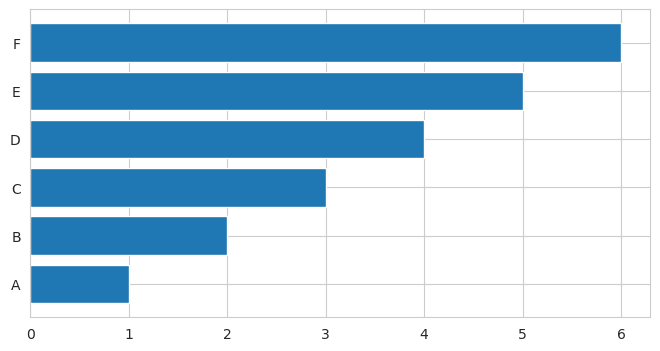

In [22]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.barh(labels, values)

<BarContainer object of 6 artists>

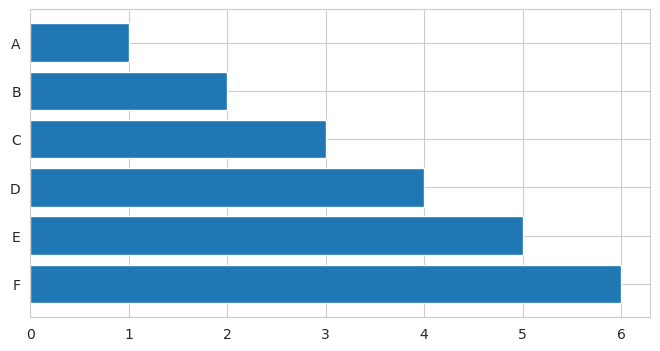

In [23]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.barh(labels[::-1], values[::-1])

<br><br>

---

In [41]:
lab = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin'])

lab = (lab[lab['region_name'].str.endswith('CA')]
    .assign(region_name= lab.region_name.str[:-11])
    .groupby('region_name', as_index=False)
    .agg({'total_homes_sold':'sum'})
    .sort_values(by='total_homes_sold', ascending=False)
    .reset_index(drop=True).iloc[:10]
)
lab

,region_name,total_homes_sold
0,Los Angeles,4622703.0
1,San Diego,2373289.0
2,Riverside,2335243.0
3,Orange,2004799.0
4,San Bernardino,1705727.0
5,Sacramento,1256838.0
6,Santa Clara,967707.0
7,Alameda,925469.0
8,Contra Costa,921039.0
9,Fresno,608004.0


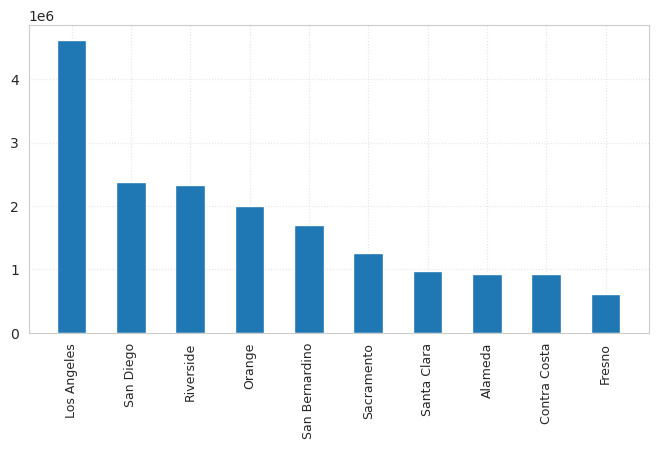

In [52]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.bar(lab.region_name, lab.total_homes_sold, 
       width=0.5)

plt.xticks(rotation=90, fontsize=9)
ax.grid(alpha=0.50, linestyle=':')
plt.show()

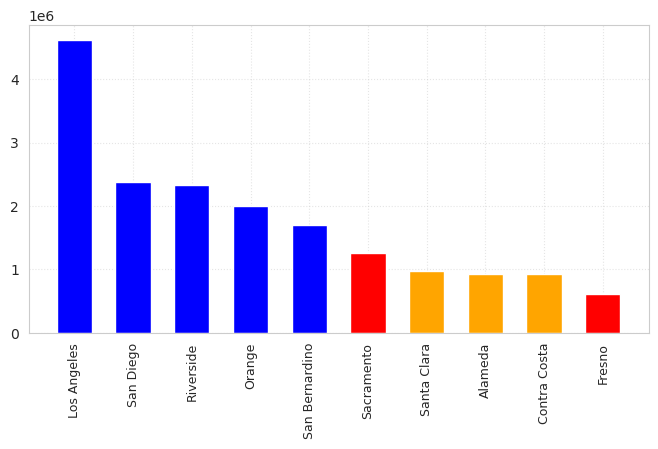

In [54]:
colors = ['blue', 'blue', 'blue', 'blue', 'blue', 'red', 'orange', 'orange', 'orange', 'red']

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.bar(lab.region_name, lab.total_homes_sold, 
       width=0.6, color=colors)

plt.xticks(rotation=90, fontsize=9)
ax.grid(alpha=0.50, linestyle=':')
plt.show()

<br><br>

---

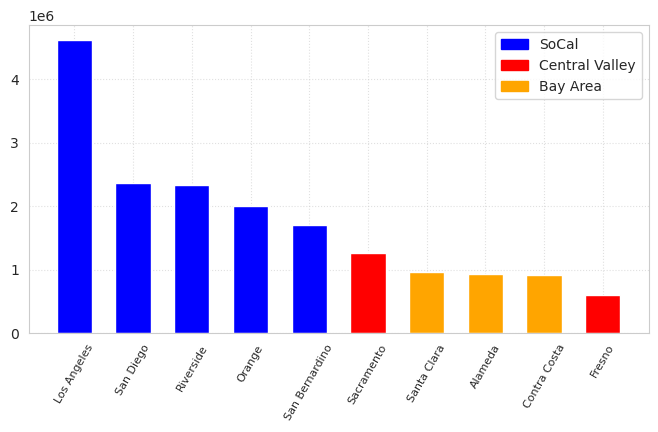

In [63]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.bar(lab.region_name, lab.total_homes_sold,
       width=0.6, color=colors)

socal = mpatches.Patch(color='blue', label='SoCal')
central = mpatches.Patch(color='red', label='Central Valley')
bay = mpatches.Patch(color='orange', label='Bay Area')

ax.legend(handles=[socal, central, bay], loc='upper right')

plt.xticks(rotation=60, fontsize=8)

ax.grid(alpha=0.6, ls=':')
plt.show()